In [623]:
import numpy as np
import gymnasium as gym
import tqdm

from tqdm.notebook import tqdm

In [624]:
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True, render_mode="rgb_array")

In [625]:
print(f'observation space: {env.observation_space}')
print(f'samle observation: {env.observation_space.sample()}')

observation space: Discrete(64)
samle observation: 12


In [626]:
print(f'action space: {env.action_space.n}')
print(f'action spce sample: {env.action_space.sample()}')

action space: 4
action spce sample: 1


In [627]:
state_space = 64
action_space = 4

In [628]:
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable

In [629]:
Qtable_frozenlake = initialize_q_table(state_space, action_space)

In [630]:
def greedy_policy(Qtable, state):
    action = np.argmax(Qtable[state][:])
    return action

In [631]:
def epsilon_greedy_policy(Qtable, state, epsilon):
    random_num = np.random.random()
    if random_num > epsilon:
        action = np.argmax(Qtable[state][:])
    else:
        action = env.action_space.sample()
    return action

In [632]:
n_training_episodes = 1000_000
learning_rate = 0.001

n_eval_episodes = 1000

env_id = "FrozenLake-v1"
max_steps = 200
gamma = 0.99
eval_seed = []

max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.000005

In [633]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    for episode in tqdm(range(n_training_episodes)):
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

        state, info = env.reset()
        step = 0
        terminated = False
        truncated = False

        for step in range(max_steps):
            action = epsilon_greedy_policy(Qtable, state, epsilon)

            new_state, reward, terminated, truncated, info = env.step(action)

            Qtable[state][action] += learning_rate * (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

            if terminated or truncated:
                break

            state = new_state
    return Qtable

In [634]:
Qtable_frozenlake = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
Qtable_frozenlake

array([[3.89436700e-01, 3.91340969e-01, 3.91348991e-01, 3.93321106e-01],
       [3.96419615e-01, 4.02573396e-01, 4.04940065e-01, 4.03246327e-01],
       [4.11376698e-01, 4.18939921e-01, 4.23798006e-01, 4.20938064e-01],
       [4.31181667e-01, 4.38398675e-01, 4.44930086e-01, 4.41644904e-01],
       [4.53113688e-01, 4.60280331e-01, 4.68009346e-01, 4.64314805e-01],
       [4.78305864e-01, 4.85638529e-01, 4.91581643e-01, 4.87183019e-01],
       [5.04576131e-01, 5.06417316e-01, 5.12834879e-01, 5.03812016e-01],
       [5.14676695e-01, 5.14420884e-01, 5.19084933e-01, 5.12668757e-01],
       [3.82998233e-01, 3.84832322e-01, 3.85999425e-01, 3.90471732e-01],
       [3.85426172e-01, 3.88378751e-01, 3.92848226e-01, 4.00005083e-01],
       [3.84818326e-01, 3.88912056e-01, 3.96444284e-01, 4.15732120e-01],
       [2.90985575e-01, 2.80861326e-01, 3.08353207e-01, 4.35536764e-01],
       [3.95716830e-01, 4.02822233e-01, 4.10494493e-01, 4.59081709e-01],
       [4.57922134e-01, 4.66841761e-01, 4.79366490e

In [636]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    episode_rewards = []
    for episode in tqdm(range(n_eval_episodes)):
        if seed:
            state, info = env.reset(seed=seed[episode])
        else:
            state, info = env.reset()
        step = 0
        truncated = False
        terminated = False
        total_rewards_ep = 0

        for step in range(max_steps):
            action = greedy_policy(Q, state)
            new_state, reward, terminated, truncated, info = env.step(action)
            total_rewards_ep += reward

            if terminated or truncated:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)

    return mean_reward, std_reward

In [637]:
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
print(f'mean reward: {mean_reward}, std reward: {std_reward}')

mean reward: 0.572, std reward: 0.494788843851597


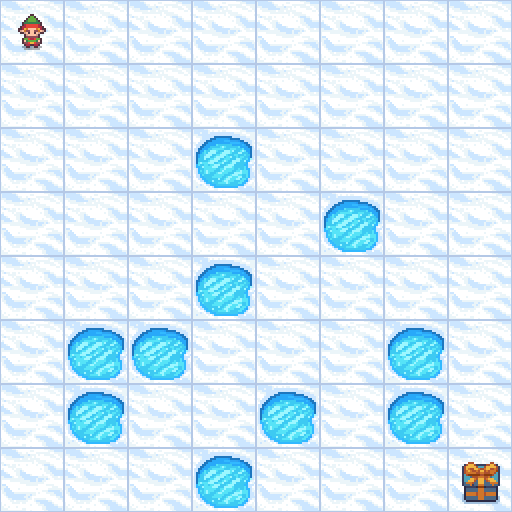

: 

In [ ]:
import gymnasium as gym
import numpy as np
import imageio.v2 as imageio
from IPython.display import Image, display

env_vis = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True, render_mode="rgb_array")
state, _ = env_vis.reset(seed=42)

frames = [env_vis.render()]
for _ in range(max_steps):
    action = int(np.argmax(Qtable_frozenlake[state]))
    state, reward, terminated, truncated, _ = env_vis.step(action)
    frames.append(env_vis.render())
    if terminated or truncated:
        break

env_vis.close()

gif_path = "frozenlake_run.gif"
imageio.mimsave(gif_path, frames, duration=0.5, loop=0)
display(Image(filename=gif_path))
